In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
superstore_df = pd.read_csv('SuperStoreOrders.csv')
superstore_df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [ ]:
# Data Cleaning
superstore_df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [9]:
superstore_df.shape

(51290, 21)

In [10]:
superstore_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [11]:
superstore_df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [17]:
superstore_df[['sales', 'profit']].dtypes

sales      object
profit    float64
dtype: object

In [34]:
superstore_df.duplicated().sum()

np.int64(0)

In [19]:
superstore_df['sales'] = (
    superstore_df['sales']
    .astype(str)
    .str.replace(',', '', regex=False)
)

superstore_df['sales'] = pd.to_numeric(superstore_df['sales'])

In [20]:
superstore_df['Profit_Margin'] = (superstore_df['profit']/superstore_df['sales'])*100

In [21]:
superstore_df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,Profit_Margin
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011,26.014706
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011,30.030000
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011,44.909091
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011,-57.900000
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011,33.131579


In [30]:
# A. General Analysis
#         Total Sales
#         Total Profit
#         Total Orders
#         Total Customers
#         Average Sales
#         Average Profit

print("Total sales : ",superstore_df['sales'].sum())
print("Total profit : ", superstore_df['profit'].sum())
print("Total orders : ", superstore_df['order_id'].count())
print("Total customers : ", len(superstore_df['customer_name'].unique()))
print("Average sales : ", superstore_df['sales'].mean())
print("Average profit : ", superstore_df['profit'].mean())

Total sales :  12642905
Total profit :  1469034.82128
Total orders :  51290
Total customers :  795
Average sales :  246.49844024176252
Average profit :  28.641739545330474


In [52]:
# B. Sales Analysis

# Total sales by year
yearly_sales = superstore_df.groupby(by='year')['year'].value_counts()
print(yearly_sales)



year
2011     8998
2012    10962
2013    13799
2014    17531
Name: count, dtype: int64


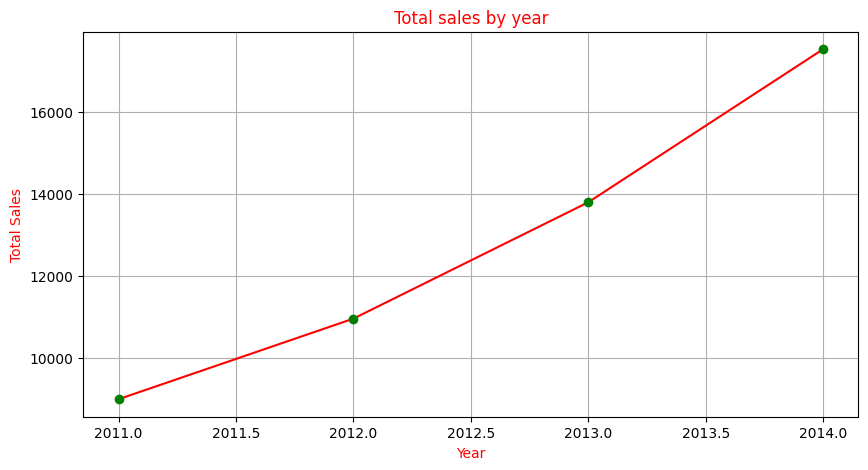

In [59]:
yearly_sales.plot(figsize=(10,5), marker='o', color='red', mfc='Green', mec='Green')
plt.xlabel("Year", color='red')
plt.ylabel("Total Sales", color='red')
plt.title("Total sales by year", color='red')
plt.grid()
plt.show()

In [36]:
superstore_df['order_date'] = pd.to_datetime(
    superstore_df['order_date'],
    format='%d/%m/%Y'
)

In [ ]:
# Monthly sales trend
superstore_df['order_date'] = pd.to_datetime(superstore_df['order_date'])
superstore_df['month'] = superstore_df['order_date'].dt.to_period('M')
monthly_sales = superstore_df.groupby('month')['sales'].sum()
print(monthly_sales)

month
2011-01     98902
2011-02     91152
2011-03    145726
2011-04    116927
2011-05    146762
2011-06    215214
2011-07    115518
2011-08    207570
2011-09    290230
2011-10    199070
2011-11    298499
2011-12    333941
2012-01    135775
2012-02    100521
2012-03    163092
2012-04    161060
2012-05    208370
2012-06    256181
2012-07    145247
2012-08    303158
2012-09    289390
2012-10    252942
2012-11    323512
2012-12    338245
2013-01    199197
2013-02    167247
2013-03    198591
2013-04    177835
2013-05    260525
2013-06    396513
2013-07    229940
2013-08    326491
2013-09    376626
2013-10    293423
2013-11    373996
2013-12    405476
2014-01    241267
2014-02    184848
2014-03    263110
2014-04    242781
2014-05    288404
2014-06    401843
2014-07    258718
2014-08    456633
2014-09    481186
2014-10    422785
2014-11    555312
2014-12    503154
Freq: M, Name: sales, dtype: int64


In [47]:
# Highest sales month
print("Highest sales : ",superstore_df.groupby(by='sales')['month'].max().max())

# Lowest sales month
print("Lowest sales : ", superstore_df.groupby(by='sales')['month'].min().min())

Highest sales :  2014-12
Lowest sales :  2011-01


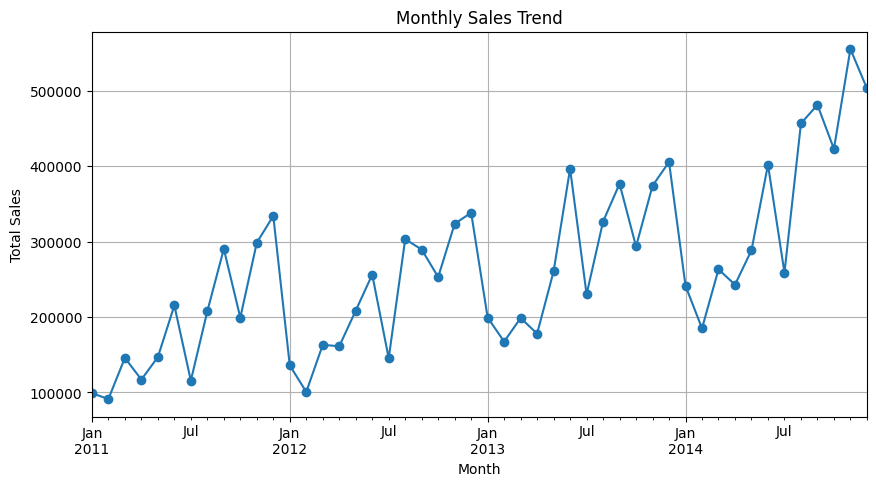

In [51]:
monthly_sales.plot(figsize=(10,5), marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

In [ ]:
# C. Profit Analysis

# Total profit
print("Total profit : ", superstore_df['profit'].sum())

# Profit by category
print("\nProfit by category : ", superstore_df.groupby(by='category')['profit'].sum())

# Profit by sub-category
print("\n Profit by sub-category : ", superstore_df.groupby(by='sub_category')['profit'].sum())

Total profit :  1469034.82128

Profit by category :  category
Furniture          286782.25380
Office Supplies    518473.83430
Technology         663778.73318
Name: profit, dtype: float64

 Profit by sub-category :  sub_category
Accessories    129626.30620
Appliances     141680.58940
Art             57953.91090
Binders         72449.84600
Bookcases      161924.41950
Chairs         141973.79750
Copiers        258567.54818
Envelopes       29601.11630
Fasteners       11525.42410
Furnishings     46967.42550
Labels          15010.51200
Machines        58867.87300
Paper           59207.68270
Phones         216717.00580
Storage        108461.48980
Supplies        22583.26310
Tables         -64083.38870
Name: profit, dtype: float64


In [80]:
# Profit by region
print("\n Profit by region : ", superstore_df.groupby(by='region')['profit'].sum())


 Profit by region :  region
Africa             88871.63100
Canada             17817.39000
Caribbean          34571.32104
Central           311403.98164
Central Asia      132480.18700
EMEA               43897.97100
East               91522.78000
North             194597.95252
North Asia        165578.42100
Oceania           121666.64200
South             140355.76618
Southeast Asia     17852.32900
West              108418.44890
Name: profit, dtype: float64


In [91]:
# Profit by state
state_wise_profit = superstore_df.groupby(by='state')['profit'].sum()
print("\n Profit by region : ", state_wise_profit)


 Profit by region :  state
Abia                      -1475.55600
Abruzzi                     977.76000
Abuja Capital Territory     -67.61400
Aceh                        -49.67430
Acre                        193.90000
                              ...    
Zinder                      122.28000
Zulia                      -994.14304
Zürich                     3393.48000
Šiauliai                   -164.73900
Žilina                       18.84000
Name: profit, Length: 1094, dtype: float64


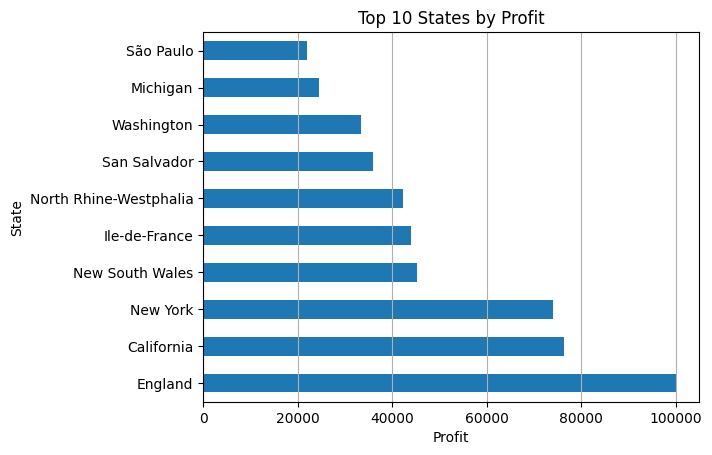

In [93]:
profit_state = superstore_df.groupby('state')['profit'].sum().sort_values(ascending=False).head(10)

profit_state.plot(kind='barh')

plt.title('Top 10 States by Profit')
plt.xlabel('Profit')
plt.ylabel('State')
plt.grid(axis='x')
plt.show()

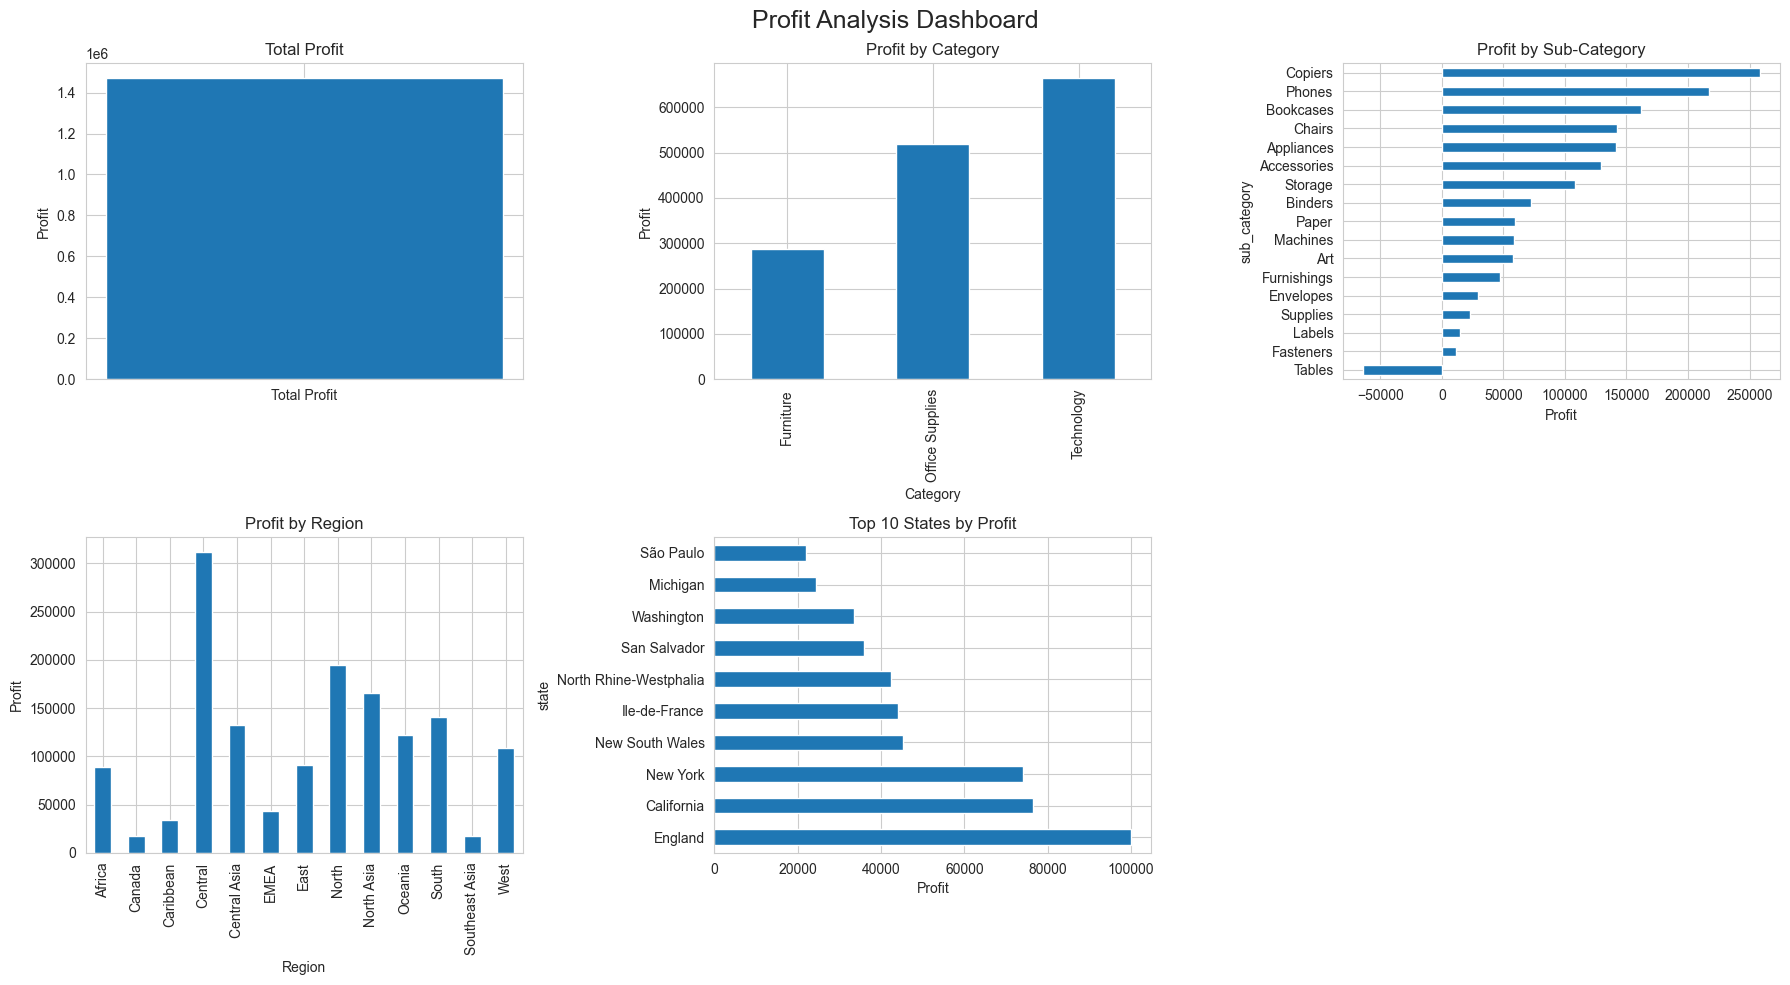

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

# 1. Total Profit
plt.subplot(2,3,1)
plt.bar(['Total Profit'], [superstore_df['profit'].sum()])
plt.title("Total Profit")
plt.ylabel("Profit")
plt.grid(True)

# 2. Profit by Category
plt.subplot(2,3,2)
superstore_df.groupby('category')['profit'].sum().plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.grid(True)

# 3. Profit by Sub-Category
plt.subplot(2,3,3)
superstore_df.groupby('sub_category')['profit'].sum().sort_values().plot(kind='barh')
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.grid(True)

# 4. Profit by Region
plt.subplot(2,3,4)
superstore_df.groupby('region')['profit'].sum().plot(kind='bar')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.grid(True)

# 5. Top 10 States by Profit
plt.subplot(2,3,5)
superstore_df.groupby('state')['profit'].sum().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 States by Profit")
plt.xlabel("Profit")
plt.grid(True)

# 6. Empty
plt.subplot(2,3,6)
plt.axis('off')

plt.suptitle("Profit Analysis Dashboard", fontsize=18)
plt.tight_layout()

plt.show()

In [115]:
# D. Product Analysis

# Top 10 selling products
top_selling_product = superstore_df.groupby(by='product_name')['sales'].sum().sort_index(ascending=False).head(10)
print("Top 10 selling products : ", top_selling_product)

# Bottom 10 selling products
print("\nBottom 10 selling products : ",superstore_df.groupby(by='product_name')['sales'].sum().sort_index(ascending=True).head(10))

Top 10 selling products :  product_name
netTALK DUO VoIP Telephone Service                                                                     1113
invisibleSHIELD by ZAGG Smudge-Free Screen Protector                                                    442
iOttie XL Car Mount                                                                                     224
iOttie HLCRIO102 Car Mount                                                                              216
iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4     479
iHome FM Clock Radio with Lightning Dock                                                                700
i.Sound Portable Power - 8000 mAh                                                                       414
Zipper Ring Binder Pockets                                                                               81
Zebra Zazzle Fluorescent Highlighters                                                           

In [117]:
# Most profitable products
print("Most profitable products : ", superstore_df.groupby(by='product_name')['profit'].sum().idxmax())

# Least profitable products
print("\nLeast profitable products : ", superstore_df.groupby(by='product_name')['profit'].sum().idxmin())

Most profitable products :  Canon imageCLASS 2200 Advanced Copier

Least profitable products :  Cubify CubeX 3D Printer Double Head Print


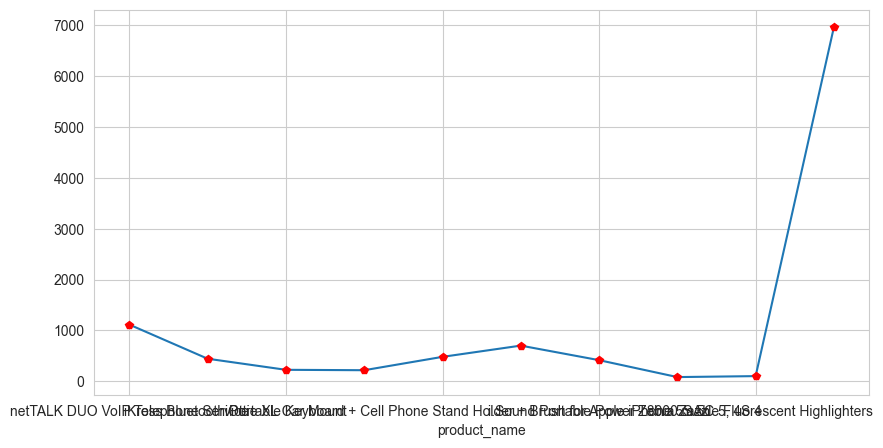

In [120]:
top_selling_product.plot(figsize=(10,5), marker='p', mfc='red', mec='red')
plt.show()

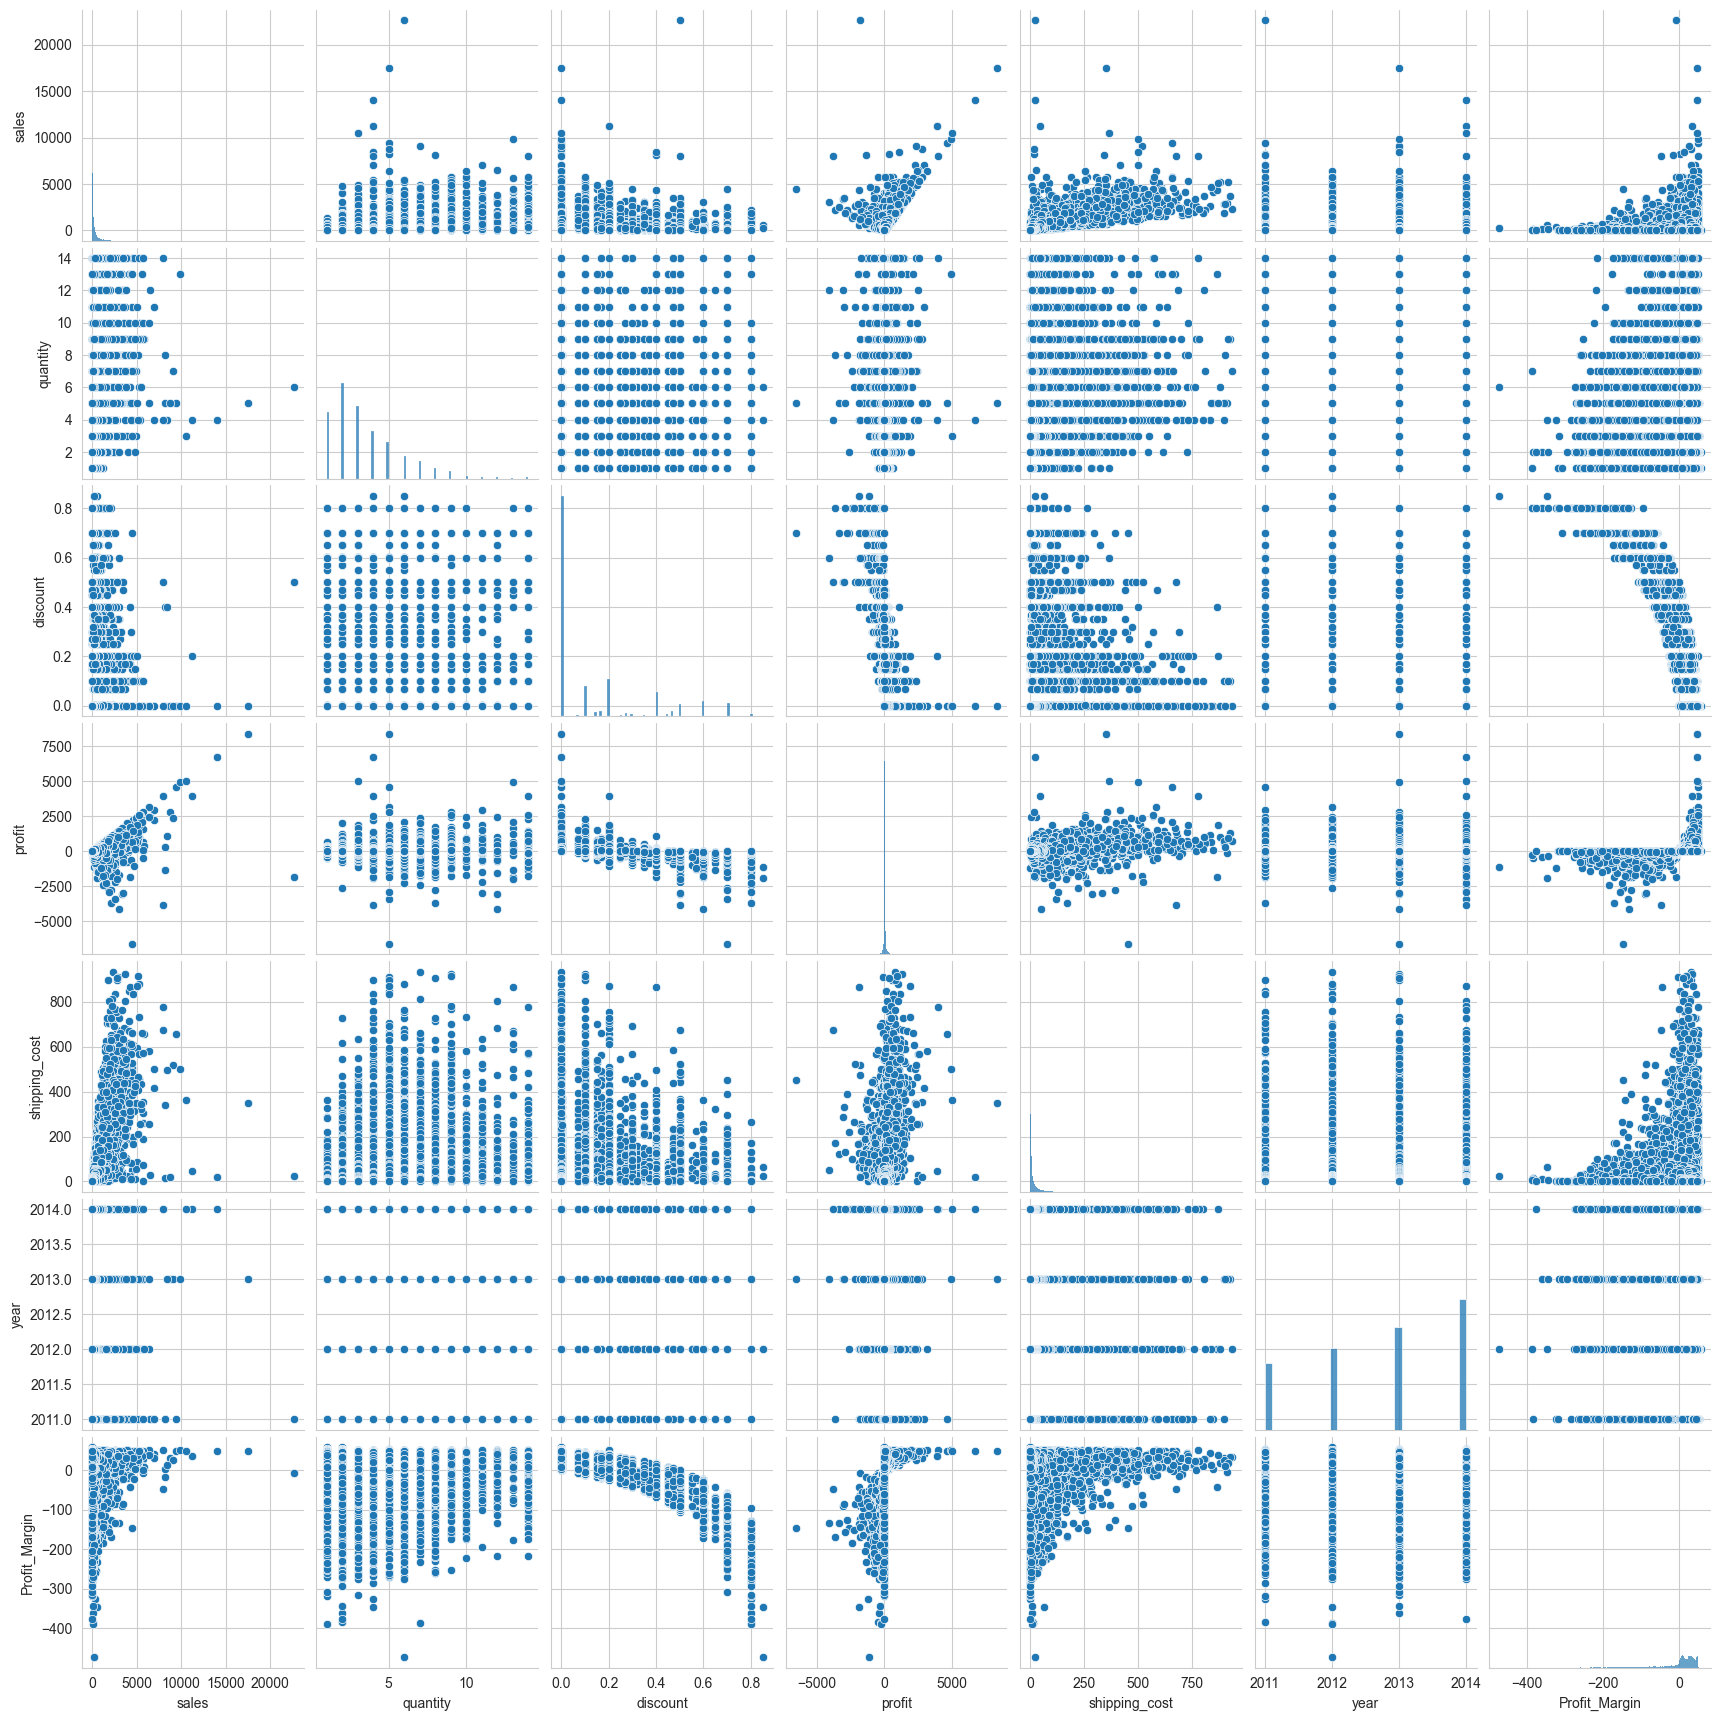

In [121]:
sns.pairplot(superstore_df)
plt.show()